This project classifies ECG heartbeats into one of five categories using the MIT-BIH Arrhythmia Dataset.

The 5 Class Labels: 
0 (N): Normal heartbeats.
1 (S): Supraventricular ectopic beats.
2 (V): Ventricular ectopic beats.
3 (F): Fusion of ventricular and normal beats.
4 (Q): Unclassifiable/Unknown beats.
The goal of this project is not to replace a cardiologist. Instead, we are building an AI-Assisted Screening Tool. 
Think of it like a "Smoke Detector" for the heart:
The Problem: Doctors and nurses are overwhelmed. They cannot watch every patient's heartbeat 24/7 on a monitor.
The AI's Job: The AI watches the screen every second. Its only goal is to "shout" (flag a notification) the moment it sees something that isn't a normal rhythm.
The Human's Job: The doctor hears the alarm, looks at the screen, and makes the final medical decision. 
Our Ultimate Goal: By training on 100% of the data later, we want to create an AI that never misses a single bad heartbeat (100% Recall), so that no patient is ever sent home with a hidden heart condition.




In [2]:
import os
# FIX: Bypass the hardware detection bug on Windows
os.environ['LOKY_MAX_CPU_COUNT'] = '4' 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle # <--- THIS LINE FIXES YOUR ERROR

# Deep Learning Imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline
plt.style.use('dark_background')
print("✅ Cell 1: Environment and Shuffle tools ready.")


✅ Cell 1: Environment and Shuffle tools ready.


In [3]:
# Load Train and Test datasets
train_df = pd.read_csv('data/mitbih_train.csv', header=None)
test_df = pd.read_csv('data/mitbih_test.csv', header=None)

X_train = train_df.iloc[:, :187].values
y_train = train_df.iloc[:, 187].values
X_test = test_df.iloc[:, :187].values
y_test = test_df.iloc[:, 187].values

In [4]:
## 3. Data Balancing (SMOTE)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# CRITICAL: Shuffle everything so the 5% slice has all 5 classes
X_train_res, y_train_res = shuffle(X_train_res, y_train_res, random_state=42)

# Now take the 5% slice (18,000 samples)
X_train_res = X_train_res[:18000]
y_train_res = y_train_res[:18000]

print(f"✅ Cell 3: Data balanced and SHUFFLED. Size: {len(X_train_res)}.")
print("Check this list - it should show roughly 3,600 for each class:")
print(pd.Series(y_train_res).value_counts()) 

D:\deep-learning-signal-processing\ecg-arrhythmia-classifier\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\deep-learning-signal-processing\ecg-arrhythmia-classifier\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


✅ Cell 3: Data balanced and SHUFFLED. Size: 18000.
Check this list - it should show roughly 3,600 for each class:
4.0    3650
2.0    3638
0.0    3631
3.0    3579
1.0    3502
Name: count, dtype: int64


In [5]:
## 4. Scaling & Saving
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

with open('scaler.pickle', 'wb') as handle:
    pickle.dump(scaler, handle)

print("✅ Cell 4: Scaler saved to 'scaler.pickle'.")


✅ Cell 4: Scaler saved to 'scaler.pickle'.


In [6]:
## 5. Reshape for LSTM (Samples, Time Steps, Features)
X_train_final = X_train_scaled.reshape(X_train_scaled.shape[0], 187, 1)
X_test_final = X_test_scaled.reshape(X_test_scaled.shape[0], 187, 1)
print(f"✅ Cell 5: Data reshaped to 3D: {X_train_final.shape}")

✅ Cell 5: Data reshaped to 3D: (18000, 187, 1)


Tips for LSTM Input
This section lists some tips to help you when preparing your input data for LSTMs.

The LSTM input layer must be 3D.
The meaning of the 3 input dimensions are: samples, time steps, and features.
The LSTM input layer is defined by the input_shape argument on the first hidden layer.
The input_shape argument takes a tuple of two values that define the number of time steps and features.
The number of samples is assumed to be 1 or more.
The reshape() function on NumPy arrays can be used to reshape your 1D or 2D data to be 3D.
The reshape() function takes a tuple as an argument that defines the new shape.

In [7]:
""" 6. Build LSTM Model
model = Sequential([
    Input(shape=(187, 1)),
    LSTM(150, return_sequences=True), 
    Dropout(0.2),
    LSTM(100),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()"""

#### Cell 6: Build 1D-CNN Model (FASTER ON CPU)
model = Sequential([
    Input(shape=(187, 1)),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("✅ Cell 6: Fast 1D-CNN architecture ready.")

✅ Cell 6: Fast 1D-CNN architecture ready.


In [8]:
## 7. Model Training
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_final, 
    y_train_res, 
    epochs=10, 
    validation_split=0.2, 
    callbacks=[early_stop],
    batch_size=32, verbose=2
)

model.save('ecg_lstm_model.keras')
print("✅ Cell 7: Model training complete and saved as 'ecg_lstm_model.keras'.")

Epoch 1/10
450/450 - 6s - 14ms/step - accuracy: 0.8088 - loss: 0.5279 - val_accuracy: 0.8658 - val_loss: 0.3521
Epoch 2/10
450/450 - 4s - 9ms/step - accuracy: 0.8967 - loss: 0.2856 - val_accuracy: 0.9042 - val_loss: 0.2496
Epoch 3/10
450/450 - 4s - 9ms/step - accuracy: 0.9206 - loss: 0.2142 - val_accuracy: 0.9228 - val_loss: 0.2158
Epoch 4/10
450/450 - 5s - 12ms/step - accuracy: 0.9380 - loss: 0.1716 - val_accuracy: 0.9267 - val_loss: 0.2084
Epoch 5/10
450/450 - 4s - 9ms/step - accuracy: 0.9524 - loss: 0.1381 - val_accuracy: 0.9381 - val_loss: 0.1691
Epoch 6/10
450/450 - 4s - 9ms/step - accuracy: 0.9616 - loss: 0.1116 - val_accuracy: 0.9503 - val_loss: 0.1524
Epoch 7/10
450/450 - 5s - 12ms/step - accuracy: 0.9695 - loss: 0.0901 - val_accuracy: 0.9519 - val_loss: 0.1496
Epoch 8/10
450/450 - 4s - 9ms/step - accuracy: 0.9735 - loss: 0.0780 - val_accuracy: 0.9578 - val_loss: 0.1378
Epoch 9/10
450/450 - 4s - 9ms/step - accuracy: 0.9770 - loss: 0.0683 - val_accuracy: 0.9611 - val_loss: 0.133

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


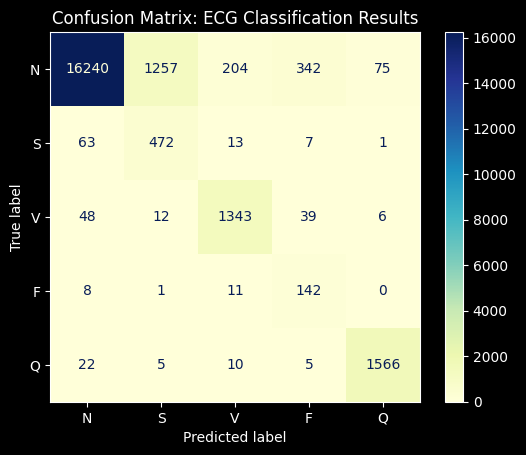

In [9]:
## Performance Evaluation

y_pred = np.argmax(model.predict(X_test_final), axis=1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['N', 'S', 'V', 'F', 'Q'])
disp.plot(cmap=plt.cm.YlGnBu)
plt.title("Confusion Matrix: ECG Classification Results")
plt.grid(False)
plt.show()

In [10]:
print("--- Raw Confusion Matrix ---")
print(cm)


--- Raw Confusion Matrix ---
[[16240  1257   204   342    75]
 [   63   472    13     7     1]
 [   48    12  1343    39     6]
 [    8     1    11   142     0]
 [   22     5    10     5  1566]]


In [11]:
import sys
print(sys.executable)


D:\deep-learning-signal-processing\ecg-arrhythmia-classifier\venv\Scripts\python.exe


In [12]:
import pandas as pd
test_data = pd.read_csv('data/mitbih_test.csv', header=None)
test_data.head(100).to_csv('sample_test.csv', index=False, header=None)

In [13]:
##  this will create a small file called test_samples.csv containing one example of every category found in your test set
# Load a small chunk of the test data
df_test = pd.read_csv('data/mitbih_test.csv', header=None)

# Get one row for every unique label (Column 187 is the label)
# 0.0 = Normal, 1.0-4.0 = Different Arrhythmias
samples = df_test.groupby(187).apply(lambda x: x.sample(1)).reset_index(drop=True)

# Save this tiny file (only 5 rows!)
samples.to_csv('test_samples.csv', index=False, header=None)

print("Created 'test_samples.csv'. Try uploading this to your Streamlit app!")
print("Labels included:", samples[187].tolist())


Created 'test_samples.csv'. Try uploading this to your Streamlit app!
Labels included: [0.0, 1.0, 2.0, 3.0, 4.0]


C:\Users\Ishaan\AppData\Local\Temp\ipykernel_21108\3621786171.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = df_test.groupby(187).apply(lambda x: x.sample(1)).reset_index(drop=True)
